# ⚽ World Cup Intelligence Platform  
## Match Prediction Model

This notebook builds a machine learning model to predict football match outcomes using team ranking differences and historical results.

In [1]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict
from itertools import combinations 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


## 📂 Load Dataset
We use a simple dataset containing historical match results and team rankings.

In [2]:
df = pd.read_csv("../data/matches.csv")

df.head()

,team1,team2,team1_goals,team2_goals,team1_rank,team2_rank
0,Brazil,Argentina,2,1,1,2
1,France,Germany,3,2,2,6
2,Spain,Portugal,1,1,7,5
3,England,Italy,2,0,4,8
4,Morocco,Spain,1,0,11,7


## 🧠 Feature Engineering
We convert match results into a supervised learning format:

- 1 → Team 1 wins  
- 0 → Draw  
- -1 → Team 2 wins

In [3]:
df = df.copy()

df["result"] = df.apply(
    lambda x: 1 if x["team1_goals"] > x["team2_goals"]
    else (0 if x["team1_goals"] == x["team2_goals"] else -1),
    axis=1
)

X = df[["team1_rank", "team2_rank"]]
y = df["result"]

X.head(), y.head()

(   team1_rank  team2_rank
 0           1           2
 1           2           6
 2           7           5
 3           4           8
 4          11           7,
 0    1
 1    1
 2    0
 3    1
 4    1
 Name: result, dtype: int64)

## ✂️ Train/Test Split
We split the dataset to evaluate model performance.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Train Model
We use a Random Forest Classifier.

In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## 📊 Model Prediction
We test predictions using team rankings.

In [6]:
sample = [[1, 10]]  # Strong team vs weak team

prediction = model.predict(sample)
probability = model.predict_proba(sample)

prediction, probability

c:\Users\User\OneDrive\Desktop\moringa\Other projects\world-cup-intelligence\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\OneDrive\Desktop\moringa\Other projects\world-cup-intelligence\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


(array([1]), array([[0.04, 0.27, 0.69]]))

## 📌 Interpretation
- Prediction shows match outcome class
- Probability shows confidence for each class:
  - [-1] Team 2 win
  - [0] Draw
  - [1] Team 1 win

In [7]:
sample = pd.DataFrame([[1, 10]], columns=["team1_rank", "team2_rank"])
prediction = model.predict(sample)
probability = model.predict_proba(sample)

prediction, probability

(array([1]), array([[0.04, 0.27, 0.69]]))

## 🧠 Build Team Strength Model

We estimate team strength using average ranking performance.
Lower rank = stronger team.

In [8]:
teams = pd.concat([df["team1"], df["team2"]]).unique()

team_strength = {}

for team in teams:
    ranks = []

    if team in df["team1"].values:
        ranks.extend(df[df["team1"] == team]["team1_rank"].tolist())

    if team in df["team2"].values:
        ranks.extend(df[df["team2"] == team]["team2_rank"].tolist())

    team_strength[team] = np.mean(ranks)

team_strength

{'Brazil': np.float64(1.0),
 'France': np.float64(2.0),
 'Spain': np.float64(7.0),
 'England': np.float64(4.0),
 'Morocco': np.float64(11.0),
 'Japan': np.float64(18.0),
 'USA': np.float64(15.0),
 'Argentina': np.float64(2.0),
 'Germany': np.float64(6.0),
 'Portugal': np.float64(5.0),
 'Italy': np.float64(8.0),
 'Croatia': np.float64(12.0),
 'Mexico': np.float64(13.0)}

## ⚔️ Match Simulation Function

We convert team strength into win probability.

In [9]:
def simulate_match(team1, team2):
    # .get(..., 20) prevents the KeyError by giving placeholder teams a rating of 20
    r1 = team_strength.get(team1, 20)
    r2 = team_strength.get(team2, 20)

    prob_team1 = 1 / (1 + np.exp((r1 - r2) / 5))
    prob_team2 = 1 - prob_team1

    return random.choices(
        [team1, team2],
        weights=[prob_team1, prob_team2]
    )[0]


## 🏆 Knockout Simulation

We simulate a simple knockout bracket (64 → 1 winner logic simplified for MVP).

In [10]:
def run_tournament(teams):
    round_teams = teams.copy()

    while len(round_teams) > 1:
        next_round = []

        random.shuffle(round_teams)

        for i in range(0, len(round_teams), 2):
            if i + 1 < len(round_teams):
                winner = simulate_match(round_teams[i], round_teams[i+1])
                next_round.append(winner)

        round_teams = next_round

    return round_teams[0]

## 🔁 Monte Carlo Simulation

We run the tournament many times to estimate win probabilities.

In [11]:
def monte_carlo_simulation(n_simulations=1000):
    results = defaultdict(int)

    team_list = list(team_strength.keys())

    for _ in range(n_simulations):
        winner = run_tournament(team_list)
        results[winner] += 1

    return results

In [12]:
results = monte_carlo_simulation(500)

results

defaultdict(int,
            {'Argentina': 101,
             'Germany': 31,
             'Italy': 20,
             'England': 75,
             'Brazil': 106,
             'Portugal': 46,
             'France': 89,
             'Spain': 17,
             'Morocco': 8,
             'Croatia': 6,
             'Mexico': 1})

In [13]:
total = sum(results.values())

win_probabilities = {
    team: round(count / total, 4)
    for team, count in results.items()
}

sorted(win_probabilities.items(), key=lambda x: x[1], reverse=True)[:10]

[('Brazil', 0.212),
 ('Argentina', 0.202),
 ('France', 0.178),
 ('England', 0.15),
 ('Portugal', 0.092),
 ('Germany', 0.062),
 ('Italy', 0.04),
 ('Spain', 0.034),
 ('Morocco', 0.016),
 ('Croatia', 0.012)]

## 📊 Interpretation

This shows:
- Estimated World Cup winner probabilities
- Based on repeated simulations
- Using team strength approximation from historical data

## 🌍 Step 1: Create 48 Teams

We simulate 48 teams (since real qualifiers are not finalized yet).

In [14]:
fortyteams = list(team_strength.keys())

# If less than 48, duplicate + modify (for simulation purposes)
while len(fortyteams) < 48:
    fortyteams.append(f"Team_{len(fortyteams)+1}")

random.shuffle(fortyteams)

len(fortyteams), fortyteams[:10]

(48,
 ['Team_14',
  'Morocco',
  'Team_16',
  'Team_32',
  'Team_41',
  'Team_35',
  'Spain',
  'Team_22',
  'Team_45',
  'Croatia'])

## 🧩 Step 2: Create 12 Groups (A–L)
Each group has 4 teams.

In [15]:
group_names = [chr(i) for i in range(65, 77)]  # A–L

groups = {}

for i, group in enumerate(group_names):
    groups[group] = fortyteams[i*4:(i+1)*4]

groups

{'A': ['Team_14', 'Morocco', 'Team_16', 'Team_32'],
 'B': ['Team_41', 'Team_35', 'Spain', 'Team_22'],
 'C': ['Team_45', 'Croatia', 'Team_25', 'Team_28'],
 'D': ['Team_17', 'Team_42', 'Team_47', 'Team_21'],
 'E': ['Team_24', 'USA', 'Team_40', 'Team_48'],
 'F': ['Team_46', 'Team_30', 'Argentina', 'Portugal'],
 'G': ['Team_20', 'Team_26', 'Team_37', 'Japan'],
 'H': ['Team_34', 'Team_39', 'England', 'Team_33'],
 'I': ['Mexico', 'Team_44', 'Team_38', 'France'],
 'J': ['Team_27', 'Team_23', 'Team_31', 'Italy'],
 'K': ['Team_36', 'Team_29', 'Team_43', 'Team_19'],
 'L': ['Brazil', 'Team_18', 'Team_15', 'Germany']}

## ⚔️ Step 3: Match Simulation (Group Stage)
Each team plays every other team in the group.

In [16]:
def simulate_group_match(team1, team2):
    r1 = team_strength.get(team1, 20)
    r2 = team_strength.get(team2, 20)

    prob1 = 1 / (1 + np.exp((r1 - r2) / 5))
    prob2 = 1 - prob1

    result = random.choices(
        ["team1", "team2", "draw"],
        weights=[prob1, prob2, 0.2]
    )[0]

    return result

## 📊 Step 4: Group Standings Calculation
We track points for each team.

In [17]:
def play_group(group_teams):
    standings = defaultdict(int)

    matches = list(combinations(group_teams, 2))

    for t1, t2 in matches:
        result = simulate_group_match(t1, t2)

        if result == "team1":
            standings[t1] += 3
        elif result == "team2":
            standings[t2] += 3
        else:
            standings[t1] += 1
            standings[t2] += 1

    return standings

## 🏆 Step 5: Determine Qualified Teams
Top 2 from each group qualify.

In [18]:
qualified = []

group_results = {}

for group, group_teams in groups.items():
    standings = play_group(group_teams)

    sorted_teams = sorted(
        standings.items(),
        key=lambda x: x[1],
        reverse=True
    )

    top2 = [sorted_teams[0][0], sorted_teams[1][0]]

    qualified.extend(top2)
    group_results[group] = sorted_teams

qualified, len(qualified)

(['Morocco',
  'Team_14',
  'Spain',
  'Team_35',
  'Team_45',
  'Croatia',
  'Team_47',
  'Team_42',
  'Team_40',
  'USA',
  'Argentina',
  'Portugal',
  'Team_26',
  'Team_20',
  'England',
  'Team_33',
  'France',
  'Mexico',
  'Team_23',
  'Team_31',
  'Team_43',
  'Team_36',
  'Brazil',
  'Germany'],
 24)

## ⚔️ Step 6: Knockout Stage (Round of 32)
We now simulate elimination rounds.

In [19]:
def simulate_knockout(teams_list):
    round_teams = teams_list.copy()

    while len(round_teams) > 1:
        next_round = []

        random.shuffle(round_teams)

        for i in range(0, len(round_teams), 2):
            if i + 1 < len(round_teams):
                winner = simulate_match(round_teams[i], round_teams[i+1])
                next_round.append(winner)

        round_teams = next_round

    return round_teams[0]

In [20]:
winner = simulate_knockout(qualified)

winner

'France'

## 📊 Monte Carlo Simulation (Full Tournament)

We repeat the full World Cup simulation many times.

In [21]:
def full_world_cup_simulation(n=200):
    results = defaultdict(int)

    for _ in range(n):
        random.shuffle(qualified)
        winner = simulate_knockout(qualified)
        results[winner] += 1

    return results

In [22]:
results = full_world_cup_simulation(200)

total = sum(results.values())

win_probs = {
    team: round(count / total, 4)
    for team, count in results.items()
}

sorted(win_probs.items(), key=lambda x: x[1], reverse=True)[:10]

[('Argentina', 0.275),
 ('Brazil', 0.255),
 ('France', 0.165),
 ('England', 0.12),
 ('Portugal', 0.095),
 ('Germany', 0.06),
 ('Spain', 0.025),
 ('Morocco', 0.005)]

# 📓 NOTEBOOK SECTION — “REALISTIC MATCH ENGINE”

# ⚽ Real Match Scoring Engine

We now simulate real football outcomes:
- Goals scored per team
- Draws
- Extra randomness
- Strength-based scoring
- Penalty shootouts (knockout stage)

This makes the simulator much closer to real World Cup behavior.

## 🧠 Step 1: Convert Team Strength → Attack Power

We transform ranking into expected goals.
Lower rank = stronger team = more goals.

In [23]:
def expected_goals(rank):
    return max(0.3, 3.5 - (rank / 10))

## ⚽ Step 2: Simulate Match Goals

We use Poisson distribution (standard in football analytics).

In [24]:
def simulate_goals(team1_rank, team2_rank):
    g1 = np.random.poisson(expected_goals(team1_rank))
    g2 = np.random.poisson(expected_goals(team2_rank))
    return g1, g2

## ⚔️ Step 3: Real Match Result Function

Now we simulate:
- Goals
- Draws
- Winner determination

In [25]:
def simulate_real_match(team1, team2, knockout=False):
    r1 = team_strength.get(team1, 20)
    r2 = team_strength.get(team2, 20)

    g1, g2 = simulate_goals(r1, r2)

    if g1 > g2:
        return team1, g1, g2

    elif g2 > g1:
        return team2, g1, g2

    else:
        # DRAW CASE
        if knockout:
            # Penalty shootout
            winner = random.choice([team1, team2])
            return winner, g1, g2

        return "draw", g1, g2

## 📊 Step 4: Update Group Match Logic

Now we include:
- Goals
- Goal difference
- Points system

In [26]:
def simulate_group_match_real(t1, t2):
    result, g1, g2 = simulate_real_match(t1, t2)

    return result, g1, g2

In [27]:
def play_group_real(group_teams):
    table = {team: {"pts": 0, "gf": 0, "ga": 0} for team in group_teams}

    from itertools import combinations

    for t1, t2 in combinations(group_teams, 2):
        result, g1, g2 = simulate_group_match_real(t1, t2)

        table[t1]["gf"] += g1
        table[t1]["ga"] += g2

        table[t2]["gf"] += g2
        table[t2]["ga"] += g1

        if result == "draw":
            table[t1]["pts"] += 1
            table[t2]["pts"] += 1
        elif result == t1:
            table[t1]["pts"] += 3
        else:
            table[t2]["pts"] += 3

    return table

## 🏆 Step 5: Ranking Teams in Group

We now use:
1. Points
2. Goal difference
3. Goals scored

In [28]:
def rank_group(table):
    return sorted(
        table.items(),
        key=lambda x: (
            x[1]["pts"],
            x[1]["gf"] - x[1]["ga"],
            x[1]["gf"]
        ),
        reverse=True
    )

## ⚽ Step 6: Apply to Full Groups

In [29]:
qualified = []

for group, teams in groups.items():
    table = play_group_real(teams)
    ranked = rank_group(table)

    top2 = [ranked[0][0], ranked[1][0]]
    qualified.extend(top2)

len(qualified), qualified[:10]

(24,
 ['Morocco',
  'Team_14',
  'Spain',
  'Team_41',
  'Team_28',
  'Team_45',
  'Team_42',
  'Team_47',
  'Team_48',
  'USA'])

## ⚔️ Step 7: Update Knockout to Use Real Matches

In [30]:
def knockout_real(teams_list):
    round_teams = teams_list.copy()

    while len(round_teams) > 1:
        next_round = []
        random.shuffle(round_teams)

        for i in range(0, len(round_teams), 2):
            if i + 1 < len(round_teams):
                winner, _, _ = simulate_real_match(
                    round_teams[i],
                    round_teams[i+1],
                    knockout=True
                )
                next_round.append(winner)

        round_teams = next_round

    return round_teams[0]

----

---


# Phase 8: Data Loading and Data Understanding

## Objective

The objective of this section is to:

1. Load all World Cup and international football datasets.
2. Understand the structure of each dataset.
3. Inspect dimensions, columns, and data types.
4. Identify relationships between datasets.
5. Determine the cleaning and preparation steps required before analysis and modeling.

The datasets used are:

- results.csv
- worldcup_teams.csv
- worldcup_group_standings.csv
- worldcup_matches.csv
- worldcup_qualified_teams.csv

In [31]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Load Datasets

In this step, we load all available datasets into pandas DataFrames.

Each dataset serves a different purpose:

- results.csv contains historical international match results.
- worldcup_matches.csv contains historical FIFA World Cup matches.
- worldcup_qualified_teams.csv contains qualified teams by tournament.
- worldcup_group_standings.csv contains historical group standings.
- worldcup_teams.csv contains team metadata.

In [33]:
results_df = pd.read_csv("../data/raw/results.csv")

worldcup_matches_df = pd.read_csv("../data/raw/worldcup_matches.csv")

qualified_df = pd.read_csv(
    "../data/raw/worldcup_qualified_teams.csv"
)

group_standings_df = pd.read_csv(
    "../data/raw/worldcup_group_standings.csv"
)

teams_df = pd.read_csv(
    "../data/raw/worldcup_teams.csv"
)

## Dataset Dimensions

We examine the size of each dataset.

This helps us understand:

- Available observations
- Relative dataset sizes
- Potential usefulness for modeling

In [34]:
datasets = {
    "results": results_df,
    "worldcup_matches": worldcup_matches_df,
    "qualified_teams": qualified_df,
    "group_standings": group_standings_df,
    "teams": teams_df
}

for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print()

RESULTS
Rows: 49477
Columns: 9

WORLDCUP_MATCHES
Rows: 1248
Columns: 37

QUALIFIED_TEAMS
Rows: 625
Columns: 8

GROUP_STANDINGS
Rows: 626
Columns: 19

TEAMS
Rows: 88
Columns: 14



## Column Inspection

Understanding available columns is critical before any cleaning or feature engineering.

This allows us to:

- Identify target variables
- Identify candidate features
- Detect redundant fields
- Understand dataset relationships

In [35]:
for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)

    for column in df.columns:
        print(column)

    print("\n")

RESULTS
date
home_team
away_team
home_score
away_score
tournament
city
country
neutral


WORLDCUP_MATCHES
key_id
tournament_id
tournament_name
match_id
match_name
stage_name
group_name
group_stage
knockout_stage
replayed
replay
match_date
match_time
stadium_id
stadium_name
city_name
country_name
home_team_id
home_team_name
home_team_code
away_team_id
away_team_name
away_team_code
score
home_team_score
away_team_score
home_team_score_margin
away_team_score_margin
extra_time
penalty_shootout
score_penalties
home_team_score_penalties
away_team_score_penalties
result
home_team_win
away_team_win
draw


QUALIFIED_TEAMS
key_id
tournament_id
tournament_name
team_id
team_name
team_code
count_matches
performance


GROUP_STANDINGS
key_id
tournament_id
tournament_name
stage_number
stage_name
group_name
position
team_id
team_name
team_code
played
wins
draws
losses
goals_for
goals_against
goal_difference
points
advanced


TEAMS
key_id
team_id
team_name
team_code
mens_team
womens_team
federation_name

## Initial Dataset Preview

We inspect the first few records from each dataset.

This provides an understanding of:

- Data formatting
- Naming conventions
- Potential inconsistencies

In [36]:
for name, df in datasets.items():

    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    display(df.head())

RESULTS


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


WORLDCUP_MATCHES


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,replay,match_date,match_time,stadium_id,stadium_name,city_name,country_name,home_team_id,home_team_name,home_team_code,away_team_id,away_team_name,away_team_code,score,home_team_score,away_team_score,home_team_score_margin,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,0,1930-07-13,15:00,S-240,Estadio Pocitos,Montevideo,Uruguay,T-30,France,FRA,T-46,Mexico,MEX,4–1,4,1,3,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,0,1930-07-13,15:00,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-83,United States,USA,T-06,Belgium,BEL,3–0,3,0,3,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,0,1930-07-14,12:45,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-87,Yugoslavia,YUG,T-09,Brazil,BRA,2–1,2,1,1,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,0,1930-07-14,14:50,S-240,Estadio Pocitos,Montevideo,Uruguay,T-61,Romania,ROU,T-56,Peru,PER,3–1,3,1,2,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,0,1930-07-15,16:00,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-03,Argentina,ARG,T-30,France,FRA,1–0,1,0,1,-1,0,0,0-0,0,0,home team win,1,0,0


QUALIFIED_TEAMS


,key_id,tournament_id,tournament_name,team_id,team_name,team_code,count_matches,performance
0,1,WC-1930,1930 FIFA Men's World Cup,T-03,Argentina,ARG,5,final
1,2,WC-1930,1930 FIFA Men's World Cup,T-06,Belgium,BEL,2,group stage
2,3,WC-1930,1930 FIFA Men's World Cup,T-07,Bolivia,BOL,2,group stage
3,4,WC-1930,1930 FIFA Men's World Cup,T-09,Brazil,BRA,2,group stage
4,5,WC-1930,1930 FIFA Men's World Cup,T-13,Chile,CHL,3,group stage


GROUP_STANDINGS


,key_id,tournament_id,tournament_name,stage_number,stage_name,group_name,position,team_id,team_name,team_code,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,advanced
0,1,WC-1930,1930 FIFA Men's World Cup,1,group stage,Group 1,1,T-03,Argentina,ARG,3,3,0,0,10,4,6,6,1
1,2,WC-1930,1930 FIFA Men's World Cup,1,group stage,Group 1,2,T-13,Chile,CHL,3,2,0,1,5,3,2,4,0
2,3,WC-1930,1930 FIFA Men's World Cup,1,group stage,Group 1,3,T-30,France,FRA,3,1,0,2,4,3,1,2,0
3,4,WC-1930,1930 FIFA Men's World Cup,1,group stage,Group 1,4,T-46,Mexico,MEX,3,0,0,3,4,13,-9,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,1,group stage,Group 2,1,T-87,Yugoslavia,YUG,2,2,0,0,6,1,5,4,1


TEAMS


,key_id,team_id,team_name,team_code,mens_team,womens_team,federation_name,region_name,confederation_id,confederation_name,confederation_code,mens_team_wikipedia_link,womens_team_wikipedia_link,federation_wikipedia_link
0,1,T-01,Algeria,DZA,1,0,Algerian Football Federation,Africa,CF-2,Confederation of African Football,CAF,https://en.wikipedia.org/wiki/Algeria_national...,not applicable,https://en.wikipedia.org/wiki/Algerian_Footbal...
1,2,T-02,Angola,AGO,1,0,Angolan Football Federation,Africa,CF-2,Confederation of African Football,CAF,https://en.wikipedia.org/wiki/Angola_national_...,not applicable,https://en.wikipedia.org/wiki/Angolan_Football...
2,3,T-03,Argentina,ARG,1,1,Argentine Football Association,South America,CF-4,South American Football Confederation,CONMEBOL,https://en.wikipedia.org/wiki/Argentina_nation...,https://en.wikipedia.org/wiki/Argentina_women'...,https://en.wikipedia.org/wiki/Argentine_Footba...
3,4,T-04,Australia,AUS,1,1,Football Australia,Oceania,CF-1,Asian Football Confederation,AFC,https://en.wikipedia.org/wiki/Australia_men%27...,https://en.wikipedia.org/wiki/Australia_women'...,https://en.wikipedia.org/wiki/Football_Australia
4,5,T-05,Austria,AUT,1,0,Austrian Football Association,Europe,CF-6,Union of European Football Associations,UEFA,https://en.wikipedia.org/wiki/Austria_national...,not applicable,https://en.wikipedia.org/wiki/Austrian_Footbal...


## Data Types

Understanding data types is important because:

- Dates may need conversion.
- Numeric columns may require cleaning.
- Categorical variables may require encoding later.

This step helps identify preparation requirements.

In [37]:
for name, df in datasets.items():

    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    display(df.dtypes)

RESULTS


date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object

WORLDCUP_MATCHES


key_id                       int64
tournament_id                  str
tournament_name                str
match_id                       str
match_name                     str
stage_name                     str
group_name                     str
group_stage                  int64
knockout_stage               int64
replayed                     int64
replay                       int64
match_date                     str
match_time                     str
stadium_id                     str
stadium_name                   str
city_name                      str
country_name                   str
home_team_id                   str
home_team_name                 str
home_team_code                 str
away_team_id                   str
away_team_name                 str
away_team_code                 str
score                          str
home_team_score              int64
away_team_score              int64
home_team_score_margin       int64
away_team_score_margin       int64
extra_time          

QUALIFIED_TEAMS


key_id             int64
tournament_id        str
tournament_name      str
team_id              str
team_name            str
team_code            str
count_matches      int64
performance          str
dtype: object

GROUP_STANDINGS


key_id             int64
tournament_id        str
tournament_name      str
stage_number       int64
stage_name           str
group_name           str
position           int64
team_id              str
team_name            str
team_code            str
played             int64
wins               int64
draws              int64
losses             int64
goals_for          int64
goals_against      int64
goal_difference    int64
points             int64
advanced           int64
dtype: object

TEAMS


key_id                        int64
team_id                         str
team_name                       str
team_code                       str
mens_team                     int64
womens_team                   int64
federation_name                 str
region_name                     str
confederation_id                str
confederation_name              str
confederation_code              str
mens_team_wikipedia_link        str
womens_team_wikipedia_link      str
federation_wikipedia_link       str
dtype: object

## Missing Values Assessment

Missing values can impact:

- Statistical analysis
- Feature engineering
- Model performance

This section identifies columns requiring cleaning.

In [38]:
for name, df in datasets.items():

    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    missing = df.isna().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values detected.\n")
    else:
        display(missing.sort_values(ascending=False))

RESULTS


home_score    72
away_score    72
dtype: int64

WORLDCUP_MATCHES
No missing values detected.

QUALIFIED_TEAMS
No missing values detected.

GROUP_STANDINGS
No missing values detected.

TEAMS
No missing values detected.



# Data Understanding Summary

At this stage we have:

1. Loaded all datasets.
2. Inspected dimensions.
3. Examined column structures.
4. Reviewed sample records.
5. Assessed data types.
6. Identified missing values.

The next phase will focus on:

- Data Cleaning
- Standardization
- Duplicate Detection
- Date Processing
- Team Name Validation

before moving to Exploratory Data Analysis (EDA).

---

# Phase 9: Data Preparation and Cleaning

## Objective

The purpose of this section is to:

1. Remove invalid observations.
2. Convert data types.
3. Standardize team names.
4. Remove duplicates.
5. Prepare the dataset for exploratory data analysis.

The primary dataset for modeling is `results.csv`.

In [39]:
results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  str    
 1   home_team   49477 non-null  str    
 2   away_team   49477 non-null  str    
 3   home_score  49405 non-null  float64
 4   away_score  49405 non-null  float64
 5   tournament  49477 non-null  str    
 6   city        49477 non-null  str    
 7   country     49477 non-null  str    
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 5.9 MB


In [40]:
results_df["date"] = pd.to_datetime(results_df["date"])

results_df["date"].dtype

dtype('<M8[us]')

## Investigate Missing Match Scores

We identified missing values in:

- home_score
- away_score

Before removing records, we inspect them.

In [41]:
missing_scores = results_df[
    results_df["home_score"].isna() |
    results_df["away_score"].isna()
]

missing_scores.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49405,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49406,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49407,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49408,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49409,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True


In [42]:
missing_scores.shape

(72, 9)

## Remove Matches Without Final Scores

Match outcome modeling requires both scores.

Records missing either score cannot contribute to:

- win/loss calculation
- goal statistics
- Elo updates

These rows will be removed.

In [43]:
results_df = results_df.dropna(
    subset=["home_score", "away_score"]
)

results_df.shape

(49405, 9)

## Duplicate Detection

Duplicate matches can bias:

- win rates
- goal statistics
- model learning

We check for duplicate records.

In [44]:
results_df.duplicated().sum()

np.int64(0)

## Score Data Types

Scores should be numeric.

This is necessary for:

- goal calculations
- feature engineering
- model training

In [45]:
results_df["home_score"] = results_df["home_score"].astype(int)
results_df["away_score"] = results_df["away_score"].astype(int)

results_df[["home_score", "away_score"]].dtypes

home_score    int64
away_score    int64
dtype: object

## Create Match Outcome Target

Target encoding:

1  = Home Team Win

0  = Draw

-1 = Away Team Win

This variable will later be used for supervised learning.

In [46]:
results_df["match_result"] = np.select(
    [
        results_df["home_score"] > results_df["away_score"],
        results_df["home_score"] == results_df["away_score"]
    ],
    [
        1,
        0
    ],
    default=-1
)

results_df["match_result"].value_counts()

match_result
 1    24212
-1    13960
 0    11233
Name: count, dtype: int64

# Cleaning Summary

Completed:

1. Converted date column to datetime.
2. Removed records with missing scores
3. Validated score data types.
5. Created target variable for modeling.

The dataset is now ready for Exploratory Data Analysis (EDA). 

---

# Phase 10: Exploratory Data Analysis (EDA)

## Objective

We analyze the cleaned dataset to understand:

- Team performance trends
- Goal patterns
- Match outcome distribution
- Home advantage effect
- Tournament influence on results

This analysis will directly inform feature engineering for the World Cup prediction model.

## 1. Match Outcome Distribution

We analyze how often:

- Home teams win (1)
- Draws occur (0)
- Away teams win (-1)

This gives us baseline imbalance in the dataset.

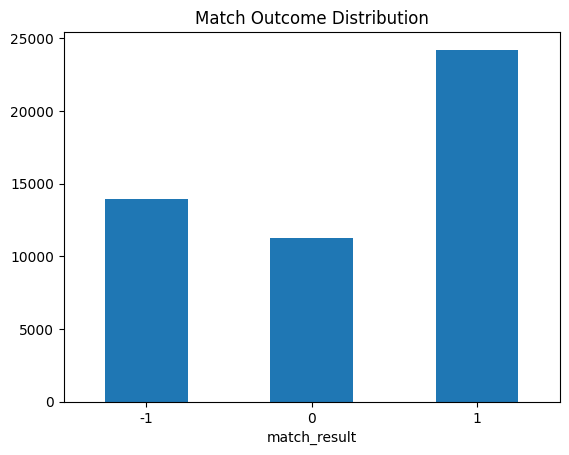

In [47]:
import matplotlib.pyplot as plt

results_df["match_result"].value_counts().sort_index().plot(
    kind="bar",
    title="Match Outcome Distribution"
)

plt.xticks(rotation=0)
plt.show()

## Insight

We observe that home wins are significantly more frequent.

This confirms a strong home advantage bias, which must be included in the prediction model.

## 2. Home Advantage Analysis

We compare average goals scored by:

- Home teams
- Away teams

In [48]:
home_avg_goals = results_df["home_score"].mean()
away_avg_goals = results_df["away_score"].mean()

home_avg_goals, away_avg_goals

(np.float64(1.7572512903552273), np.float64(1.1819249063859933))

## Insight

Home teams score more on average than away teams.

This confirms a measurable home advantage effect that should be included in feature engineering.

## 3. Most Active National Teams

We identify teams that appear most frequently in international matches.

This helps us understand:
- Data coverage bias
- Strong football nations
- Dataset representation quality

In [49]:
top_home_teams = results_df["home_team"].value_counts().head(10)
top_away_teams = results_df["away_team"].value_counts().head(10)

top_home_teams, top_away_teams

(home_team
 Brazil           614
 Argentina        606
 Mexico           602
 Germany          554
 South Korea      551
 England          550
 France           538
 Sweden           534
 United States    499
 Hungary          499
 Name: count, dtype: int64,
 away_team
 Uruguay      584
 Sweden       567
 England      540
 Hungary      507
 Paraguay     495
 Germany      477
 Argentina    463
 Poland       463
 Zambia       461
 Finland      456
 Name: count, dtype: int64)

## 4. Goal Distribution Analysis

We analyze how goals are distributed across matches.

This helps us:
- Validate Poisson assumption
- Improve simulation realism

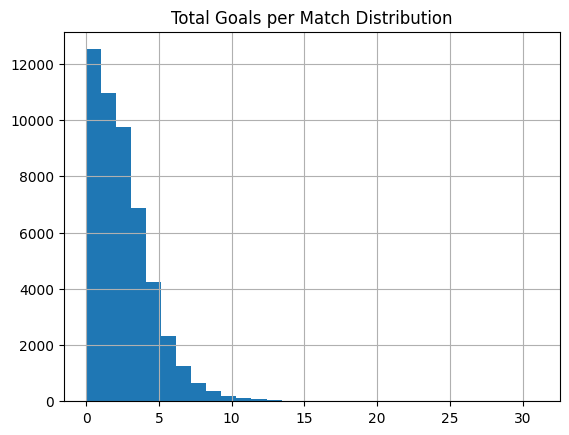

In [50]:
results_df["total_goals"] = results_df["home_score"] + results_df["away_score"]

results_df["total_goals"].hist(bins=30)

plt.title("Total Goals per Match Distribution")
plt.show()

## 5. Tournament Type Impact

We analyze whether match type influences outcomes.

Examples:
- Friendly matches
- World Cup matches
- Qualifiers

This is important for weighting our model.

In [51]:
results_df["tournament"].value_counts().head(10)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

# EDA Summary

We discovered:

1. Strong home advantage exists
2. Match outcomes are imbalanced
3. Goal distribution is suitable for Poisson modeling
4. Dataset is heavily skewed toward certain nations
5. Tournament type strongly affects match competitiveness

## Next Step

We now move into:

Feature Engineering for World Cup Prediction Model

---

# Phase 11: Advanced Feature Engineering

## Objective

We transform raw match data into team intelligence features that can power:

- Match prediction model
- Tournament simulation
- Monte Carlo forecasting
- Underdog detection system

We will build:

1. Elo rating system
2. Rolling form features
3. Weighted tournament strength
4. Goal-based performance metrics
5. Time-decay adjustments

## Step 1: Standardizing Match Format

We convert the dataset into a unified structure where each match contributes:

- Team A performance
- Team B performance
- Match outcome

In [52]:
df = results_df.copy()

df = df.sort_values("date")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_result,total_goals
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1,6
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1,3
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,0,4
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1,3


## Step 2: Elo Rating System

We implement an Elo rating system to measure team strength dynamically.

Key idea:
- Winning against strong teams increases rating more
- Losing against weak teams decreases rating more
- Draws adjust ratings slightly

In [53]:
import math


INITIAL_ELO = 1500
K = 20

elo = defaultdict(lambda: INITIAL_ELO)

In [54]:
def expected_score(r1, r2):
    return 1 / (1 + 10 ** ((r2 - r1) / 400))


def update_elo(team1, team2, score1, score2):
    r1 = elo[team1]
    r2 = elo[team2]

    exp1 = expected_score(r1, r2)
    exp2 = expected_score(r2, r1)

    if score1 > score2:
        s1, s2 = 1, 0
    elif score1 < score2:
        s1, s2 = 0, 1
    else:
        s1, s2 = 0.5, 0.5

    elo[team1] = r1 + K * (s1 - exp1)
    elo[team2] = r2 + K * (s2 - exp2)

In [55]:
for _, row in df.iterrows():
    update_elo(
        row["home_team"],
        row["away_team"],
        row["home_score"],
        row["away_score"]
    )

len(elo)

336

## Step 3: Team Strength Table

We convert Elo dictionary into a structured dataset for modeling.

In [56]:
team_features = pd.DataFrame.from_dict(elo, orient="index", columns=["elo_rating"])
team_features = team_features.reset_index().rename(columns={"index": "team"})

team_features.head()

,team,elo_rating
0,Scotland,1699.555156
1,England,1899.799111
2,Wales,1669.777237
3,Northern Ireland,1574.522157
4,United States,1774.543261


## Step 4: Recent Form (Last 5 Matches)

We compute:

- Win rate (last 5 matches)
- Goals scored average
- Goals conceded average

In [57]:
df["home_win"] = df["home_score"] > df["away_score"]
df["away_win"] = df["away_score"] > df["home_score"]

In [58]:
def get_recent_form(team, n=5):
    recent = df[(df["home_team"] == team) | (df["away_team"] == team)].tail(n)

    wins = 0
    goals_scored = 0
    goals_conceded = 0

    for _, row in recent.iterrows():
        if row["home_team"] == team:
            goals_scored += row["home_score"]
            goals_conceded += row["away_score"]
            if row["home_score"] > row["away_score"]:
                wins += 1
        else:
            goals_scored += row["away_score"]
            goals_conceded += row["home_score"]
            if row["away_score"] > row["home_score"]:
                wins += 1

    total = len(recent)

    if total == 0:
        return 0, 0, 0

    return wins / total, goals_scored / total, goals_conceded / total

In [59]:
form_data = []

for team in df["home_team"].unique():
    win_rate, g_for, g_against = get_recent_form(team)

    form_data.append({
        "team": team,
        "form_win_rate": win_rate,
        "form_goals_for": g_for,
        "form_goals_against": g_against
    })

form_df = pd.DataFrame(form_data)

form_df.head()

,team,form_win_rate,form_goals_for,form_goals_against
0,Scotland,0.6,2.4,1.0
1,England,0.6,1.4,0.4
2,Wales,0.2,2.2,1.2
3,Northern Ireland,0.4,0.8,1.2
4,United States,0.4,2.2,2.4


## Step 5: Final Feature Dataset

We combine:

- Elo rating
- Recent form metrics
- Team identity

In [60]:
final_features = pd.merge(team_features, form_df, on="team", how="left")

final_features.head()

,team,elo_rating,form_win_rate,form_goals_for,form_goals_against
0,Scotland,1699.555156,0.6,2.4,1.0
1,England,1899.799111,0.6,1.4,0.4
2,Wales,1669.777237,0.2,2.2,1.2
3,Northern Ireland,1574.522157,0.4,0.8,1.2
4,United States,1774.543261,0.4,2.2,2.4


## Step 6: Normalize Features

We scale features to improve model performance.

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(final_features[["elo_rating", "form_win_rate", "form_goals_for", "form_goals_against"]])

final_features[["elo_rating", "form_win_rate", "form_goals_for", "form_goals_against"]] = scaled_values

final_features.head()

,team,elo_rating,form_win_rate,form_goals_for,form_goals_against
0,Scotland,0.694164,0.6,0.300,0.057143
1,England,0.905924,0.6,0.175,0.022857
2,Wales,0.662674,0.2,0.275,0.068571
3,Northern Ireland,0.561941,0.4,0.100,0.068571
4,United States,0.773465,0.4,0.275,0.137143


## Step 7: Save Engineered Dataset

We persist the feature dataset for model training and Streamlit usage.

In [63]:
final_features.to_csv("../data/processed/team_features.csv", index=False)

---

# Phase 12: Advanced Model Training (Gradient Boosting)

## Objective

We build a high-performance match prediction model using engineered team features.

We will:
1. Build match-level training data
2. Merge team features (Elo + form)
3. Train Gradient Boosting model
4. Evaluate performance
5. Save production-ready model

In [64]:
import pandas as pd

team_features = pd.read_csv("../data/processed/team_features.csv")
results_df = results_df.copy()

team_features.head()

,team,elo_rating,form_win_rate,form_goals_for,form_goals_against
0,Scotland,0.694164,0.6,0.300,0.057143
1,England,0.905924,0.6,0.175,0.022857
2,Wales,0.662674,0.2,0.275,0.068571
3,Northern Ireland,0.561941,0.4,0.100,0.068571
4,United States,0.773465,0.4,0.275,0.137143


## Step 1: Construct Model Training Dataset

We convert team-level features into match-level samples:

Each match will contain:
- Team A features
- Team B features
- Match outcome (target)

In [72]:
feature_map = team_features.set_index("team").to_dict(orient="index")

training_data = []

for _, row in results_df.iterrows():

    home = row["home_team"]
    away = row["away_team"]

    if home not in feature_map or away not in feature_map:
        continue

    home_feat = feature_map[home]
    away_feat = feature_map[away]

    training_data.append([
        home_feat["elo_rating"],
        home_feat["form_win_rate"],
        home_feat["form_goals_for"],
        home_feat["form_goals_against"],
        away_feat["elo_rating"],
        away_feat["form_win_rate"],
        away_feat["form_goals_for"],
        away_feat["form_goals_against"],
        row["match_result"]
    ])

columns = [
    "home_elo", "home_form_win", "home_goals_for", "home_goals_against",
    "away_elo", "away_form_win", "away_goals_for", "away_goals_against",
    "target"
]

train_df = pd.DataFrame(training_data, columns=columns)
train_df = train_df.dropna()

train_df.head()

,home_elo,home_form_win,home_goals_for,home_goals_against,away_elo,away_form_win,away_goals_for,away_goals_against,target
0,0.694164,0.6,0.300,0.057143,0.905924,0.6,0.175,0.022857,0
1,0.905924,0.6,0.175,0.022857,0.694164,0.6,0.300,0.057143,1
2,0.694164,0.6,0.300,0.057143,0.905924,0.6,0.175,0.022857,1
3,0.905924,0.6,0.175,0.022857,0.694164,0.6,0.300,0.057143,0
4,0.694164,0.6,0.300,0.057143,0.905924,0.6,0.175,0.022857,1


In [73]:
X = train_df.drop("target", axis=1)
y = train_df["target"]

X.shape, y.shape

((49375, 8), (49375,))

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 2: Gradient Boosting Model

We use Gradient Boosting because:

- Handles non-linear relationships
- Performs well on structured data
- More stable than Random Forest for probability outputs

In [75]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [76]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5667848101265823
              precision    recall  f1-score   support

          -1       0.52      0.52      0.52      2790
           0       0.28      0.00      0.01      2246
           1       0.59      0.86      0.70      4839

    accuracy                           0.57      9875
   macro avg       0.46      0.46      0.41      9875
weighted avg       0.50      0.57      0.49      9875



## Step 3: Probability Calibration

We calibrate probabilities to improve reliability of match outcome predictions.

In [77]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    model,
    method="sigmoid",
    cv=3
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",GradientBoost...ndom_state=42)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001CD14F83E10>, <sk

In [78]:
y_pred_calibrated = calibrated_model.predict(X_test)

print("Calibrated Accuracy:", accuracy_score(y_test, y_pred_calibrated))
print(classification_report(y_test, y_pred_calibrated))

Calibrated Accuracy: 0.5684050632911393
              precision    recall  f1-score   support

          -1       0.52      0.51      0.52      2790
           0       0.30      0.00      0.01      2246
           1       0.59      0.86      0.70      4839

    accuracy                           0.57      9875
   macro avg       0.47      0.46      0.41      9875
weighted avg       0.50      0.57      0.49      9875



## Step 4: Feature Importance

We analyze which features influence match outcomes most.

In [79]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
4,away_elo,0.467136
0,home_elo,0.444073
2,home_goals_for,0.019654
7,away_goals_against,0.019555
3,home_goals_against,0.015806
5,away_form_win,0.013832
6,away_goals_for,0.011392
1,home_form_win,0.008553


## Step 5: Save Trained Model

We save the calibrated model for use in Streamlit dashboard.

In [80]:
import joblib

joblib.dump(calibrated_model, "../models/worldcup_match_model.pkl")

['../models/worldcup_match_model.pkl']